In [1]:
import numpy as np
from scipy.optimize import fsolve, root

# import predefined functions wich solve the box model
import fct_BoxModel as fbm

import xarray as xr
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import cv2 as cv

from matplotlib import colors




matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

### Importing the model inputs

In [2]:
inputs = xr.open_dataset("model_input_dataset.nc")
index_isf = inputs.Nisf.values
name_isf = inputs.name_isf.values

outputs = xr.open_dataset("model_output_dataset.nc")

### Defining constant parameters of the model

In [3]:
# Define reference properties and parameters 

#EOS
T_star = 0 # °C  (PICO)
S_star = 34 # PSU   (PICO)
rho_star = 1033 # kg/m^3   (PICO)
alpha = 7.5e-5 # /°C   (PICO)
beta = 7.7e-4 # /PSU (PICO)

def EOS(T,S):
    return rho_star*(1-alpha*(T-T_star)+beta*(S-S_star))
    
#Liquidus
la = -0.0572 # °C/PSU   (PICO)
lb = 0.0788 # °C   (PICO)
lc = 7.59e-4 # °C/m   (PICO->Burgard)

def liquidus(S,h):
    return la*S+lb-lc*h

#Water properties
L = 3.34e5 # J/kg   (PICO)
c_star = 3974 # J/kg/°C   (PICO)
lambd = L/c_star # 84 K

#Ice properties
rho_i = 910 # kg/m^3   (PICO)
nu = rho_i/rho_star #0.88

#PICO parameters
# Reese 2018
C = 1e6 #m^6/s/kg
gammaT = 2e-5 #m/s

#Vertical mixing
# ~Olbers & Hellmer 2010
kappa_diff = 1e-7  # m/s
kappa_conv = 1e-3 # m/s

#Polynia
g = 20

#AABW
C_DSW = 4e6 #m^6/s/kg

# fraction of q_cav that sinks
r_conv = 0.

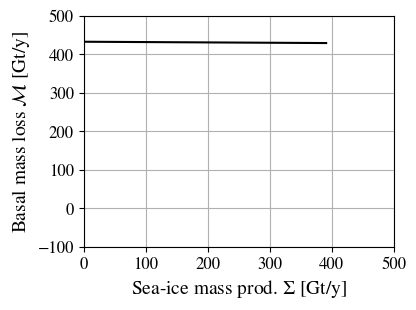

In [21]:
#try with eddy intrusion of CDW

import imp
imp.reload(fbm)

index = 31 #Amery ice shelf


nbox = int(inputs.Nbox.sel(Nisf=index).values)
Ac = inputs.Ac.sel(Nisf=index).values #m^2
xi = np.mean(inputs.xi.sel(Nisf=index).values)/30/24/3600 *2/3 #m/s factor 2/3 to take summer into account
Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values) *2/3 #m factor 2/3 to take summer into account
melt_ref_conv = outputs.melt.sel(Nisf=index, regime='conv').values *12 #m/y
frac = inputs.frac.sel(Nisf=index).values
depth = inputs.depth.sel(Nisf=index).values
T_surf = np.mean(inputs.T_surf.sel(Nisf=index).values)
S_surf = np.mean(inputs.S_surf.sel(Nisf=index).values)
T_CDW = np.mean(inputs.T_CDW.sel(Nisf=index).values)
S_CDW = np.mean(inputs.S_CDW.sel(Nisf=index).values)

Ap_min = 0.
Ap_max = 80e9
Npoints = 1000
list_Ap = np.linspace(Ap_min,Ap_max,Npoints)

AABW = False

guess_diff = np.array([0,0,34.5,34.54])
guess_conv = np.array([-1.8,-1.5,34.3,35.5])


plt.figure(figsize=(4,3))

for kappa, guess, sign, r in zip([kappa_diff, kappa_conv],[guess_diff,guess_conv],[-1,1],[0,r_conv]):
    

    if sign==1: 
        break

    melt_list = []
    overt = []
    Sd_list = []
    sig = []
    
    for Ap in list_Ap:

        X, info, ier, msg = fsolve(fbm.BoxModel, guess, args = (nbox, C, gammaT, Ac, xi, T_CDW, S_CDW, Ap, kappa, g, frac, depth, r), full_output=True)
        if ier != 1: #management of non convergence cases
            while ier != 1:
                X, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess,0.1), args = (nbox, C, gammaT, Ac, xi, T_CDW, S_CDW, Ap, kappa, g, frac, depth, r), full_output=True)
            print(msg,sign,Ap)
        guess = X

        Tp, Td, Sp, Sd = X
        sigma = fbm.compute_Sigma(X)
                

        T,S,melt,q = fbm.PICO(Td, Sd, nbox, C, gammaT, Ac, frac, depth)
        q_DSW = fbm.compute_DSW(Td, Sd, C_DSW, T_CDW, S_CDW)
        m_avg = fbm.compute_m_avg(melt,frac,nbox)
        
        
        melt_list.append(m_avg*12) #m/y
        overt.append(q/1e6) #Sv
        Sd_list.append(Sd) #PSU
        sig.append(sigma)
    
    stab = (np.array(sig)*sign > 0)
    melt_list = np.ma.masked_where(np.logical_not(stab),np.array(melt_list))
    overt = np.ma.masked_where(np.logical_not(stab),np.array(overt))
    Sd_list = np.ma.masked_where(np.logical_not(stab),np.array(Sd_list))
    
    x_axis = np.ma.masked_where(np.logical_not(stab),list_Ap) *xi*rho_i/1e12*3600*24*365.25 # Gt/y
    y_axis = melt_list*Ac*rho_i/1e12 # Gt/y

    plt.plot(x_axis,y_axis,c='black')





#plt.hlines(0,0,np.max(x_axis), colors='black',linestyle='dotted')

# Reference point with current conditions
#plt.scatter(rho_i*Ap_ref*xi*3600*24*365.25/1e12,rho_i*melt_ref_conv*Ac/1e12,facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1, zorder=2) 

plt.ylim((-100,500))
plt.xlim((0,500))
plt.xlabel(r'Sea-ice mass prod. $\Sigma$ [Gt/y]')
plt.ylabel(r'Basal mass loss $\mathcal{M}$ [Gt/y]')
plt.grid()
plt.savefig('Figures/Figure2.pdf',format="pdf", bbox_inches = 'tight')
plt.show()